# UAV-SVI student workflow
Run top to bottom from the repository root. Pairs are always built for **one specific OSM building** (UAV chip: that building's footprint; SVI chip: the viewing angle from the camera to that building). Finding good buildings is your job: check every pair visually before labelling.

In [3]:
import os, sys, subprocess
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, 'scripts')
# %pip install -q -r requirements.txt ipywidgets matplotlib

def run(script, *args):
    """Run a pipeline script and stream its output (including progress bars) into this notebook."""
    cmd = [sys.executable, f'scripts/{script}', *map(str, args)]
    print('$', ' '.join(cmd))
    env = {**os.environ, 'PYTHONUNBUFFERED': '1'}
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, env=env)
    while chunk := proc.stdout.read1(1024):
        print(chunk.decode(errors='replace'), end='', flush=True)
    if proc.wait():
        raise RuntimeError(f'{script} failed with exit code {proc.returncode}')

## 1. Load your package and choose scenes

In [4]:
import geopandas as gpd
NAME = 'your_name'                                     # letters, digits, _ and - only
PACKAGE = 'data/input/packages/student_02_scenes.gpkg'    # the package you claimed in the Google Sheet

scenes = gpd.read_file(PACKAGE)
scenes['scene_id'] = scenes['scene_id'].astype(str)
display(scenes.drop(columns='geometry')[['scene_id', 'country', 'title', 'gsd_cm', 'area_km2', 'valid_los_matches']])
# scenes.plot(column='valid_los_matches', legend=True, figsize=(8, 5));

,scene_id,country,title,gsd_cm,area_km2,valid_los_matches
0,5ae3ac2d0b093000130aff91,United Republic of Tanzania,U_196_V1,2.518,1.6873,17
1,6a215d33c01a692b78adbf26,Bangladesh,Chattogram UAV 34,3.000,4.1492,2
2,6a1eb95693c47b7abc1c2270,Bangladesh,Chattogram UAV 14,3.000,2.9369,26
3,5a95b6e35a9ef7cb5d8e0720,Puerto Rico,Roseau - Dominica 3-2,3.132,1.1816,3
4,68b9288a933f12d326a7658f,Canada,Poplar Ridge,3.148,1.8415,0
5,59f7695dbac48e5b1ce04b10,Puerto Rico,Mahaut - Dominica,3.207,1.1775,21
6,5c892a92225fc20007ab4e31,United Kingdom,NEWRY CITY CORE. UAV SURVEY 2018.,3.243,1.1914,17
7,68cdf39e4b37dca55fe3714b,Canada,Outpost,3.311,1.6216,0
8,68cb9b33fea39f0ce18bf0cc,Canada,Sportys Uncorrected,3.446,1.2847,4
9,68cecfaabba38109e3899e34,Canada,South Onanole,3.482,3.4129,1


In [4]:
# OAM scene ids to work on, from the table above (one or several).
SCENE_IDS = ['5ae3ac2d0b093000130aff91']
ALL_SCENES_IN_PACKAGE = False    # True = ignore SCENE_IDS and take every scene of PACKAGE

## 2. Download UAV raster, OSM buildings (ways and relations) and Mapillary points
The raster link is looked up through the OpenAerialMap API. Everything is cached, so you can re-run safely. Needs `MAPILLARY_ACCESS_TOKEN` in `.env`.

In [7]:
if ALL_SCENES_IN_PACKAGE:
    run('01_download.py', '--package', os.path.basename(PACKAGE))
else:
    run('01_download.py', '--scene-ids', *SCENE_IDS)

$ c:\Users\gisadmin\miniconda3\envs\geotessera_env\python.exe scripts/01_download.py --scene-ids 5ae3ac2d0b093000130aff91
[5ae3ac2d0b093000130aff91] U_196_V1  gsd 2.5 cm 
Scenes:   0%|          | 0/1 [00:00<?, ?scene/s]
5ae3ac2d0b093000130aff91.tif:   0%|          | 0.00/466M [00:00<?, ?B/s]
5ae3ac2d0b093000130aff91.tif:   0%|          | 1.05M/466M [00:03<23:09, 335kB/s]
5ae3ac2d0b093000130aff91.tif:   0%|          | 2.10M/466M [00:06<22:04, 350kB/s]
5ae3ac2d0b093000130aff91.tif:   1%|          | 3.15M/466M [00:09<22:15, 346kB/s]
5ae3ac2d0b093000130aff91.tif:   1%|          | 4.19M/466M [00:11<20:12, 381kB/s]
5ae3ac2d0b093000130aff91.tif:   1%|          | 5.24M/466M [00:13<18:52, 407kB/s]
5ae3ac2d0b093000130aff91.tif:   2%|▏         | 7.34M/466M [00:18<17:28, 437kB/s]
5ae3ac2d0b093000130aff91.tif:   2%|▏         | 8.39M/466M [00:20<17:12, 443kB/s]
5ae3ac2d0b093000130aff91.tif:   2%|▏         | 9.44M/466M [00:22<16:55, 450kB/s]
5ae3ac2d0b093000130aff91.tif:   2%|▏         | 10.5M/466M [

### 2b. Optional: merge overlapping scenes
Only if a building you want is cut by a scene border. Needs at least two scene ids from `SCENE_IDS`.

In [ ]:
MERGE = False   # needs at least two scenes in SCENE_IDS; do not re-run step 2 afterwards
if MERGE:
    run('00f_merge_overlaps.py', '--scene-ids', *SCENE_IDS)

## 3. Parameters you can tweak

In [ ]:
LIMIT = 40                # number of pairs for a first run (None = every building with a valid line of sight)
PANO_ONLY = True          # True = 360 panoramas only (first run); set False later to add ordinary photos
OSM_IDS_CSV = None        # optional CSV with an osm_id column (e.g. exported from QGIS) to restrict the buildings
SEARCH_RADIUS_M = 30      # max camera-to-building distance
FOV_DEG = 50              # max angle between camera heading and building (non-panorama images)
PADDING_FACTOR = 1.25     # UAV chip size relative to the building
MANUAL_PAIRS = None       # e.g. 'submission/selected_pairs.csv' from the QGIS plugin
ONLY_MANUAL = False       # True = only build pairs for buildings listed in MANUAL_PAIRS

## 4. Create the pairs (line of sight, UAV mask, SVI crop) and package them

In [ ]:
args = ['--search-radius', SEARCH_RADIUS_M, '--fov', FOV_DEG, '--padding-factor', PADDING_FACTOR]
if PANO_ONLY:
    args += ['--pano-only']
if not ALL_SCENES_IN_PACKAGE:
    args += ['--scene-ids', *SCENE_IDS]
if LIMIT:
    args += ['--limit', LIMIT]
if OSM_IDS_CSV:
    args += ['--osm-ids-csv', OSM_IDS_CSV]
if MANUAL_PAIRS:
    args += ['--manual-pairs', MANUAL_PAIRS] + (['--only-manual'] if ONLY_MANUAL else [])
run('02_make_pairs.py', *args)
run('03_package_pairs.py', '--name', NAME)

$ c:\Users\gisadmin\miniconda3\envs\geotessera_env\python.exe scripts/02_make_pairs.py --search-radius 30 --fov 50 --padding-factor 1.25 --scene-ids 5ae3ac2d0b093000130aff91 --limit 40
[5ae3ac2d0b093000130aff91] line of sight: 100%|██████████| 514/514 [00:00<00:00, 685.51bld/s]
[5ae3ac2d0b093000130aff91] 26 of 514 buildings have a valid line of sight
[5ae3ac2d0b093000130aff91] chips: 100%|██████████| 26/26 [20:51<00:00, 48.15s/pair]
26 pairs in \\lsdf02.urz.uni-heidelberg.de\sd17f001\steffen_knoblauch\waste_labels\repo\UAV-SVI-Annotation-Pipeline\data\output_pairs (0 failed, 0 UAV chips empty/outside the image). Provenance: \\lsdf02.urz.uni-heidelberg.de\sd17f001\steffen_knoblauch\waste_labels\repo\UAV-SVI-Annotation-Pipeline\data\intermediate\pairs_assignments.csv
$ c:\Users\gisadmin\miniconda3\envs\geotessera_env\python.exe scripts/03_package_pairs.py --name your_name
26 complete pairs -> \\lsdf02.urz.uni-heidelberg.de\sd17f001\steffen_knoblauch\waste_labels\repo\UAV-SVI-Annotation-P

### 4b. Look at the pairs first
Drop pairs where the building is not clearly the one in both views (delete `submission/uav/<id>.png`, `submission/svi/<id>.png` and the CSV row, or re-run step 4 with different parameters).

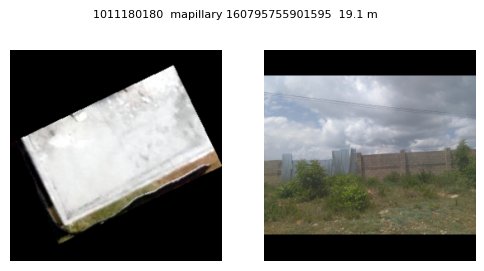

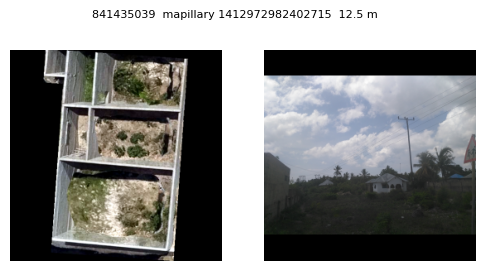

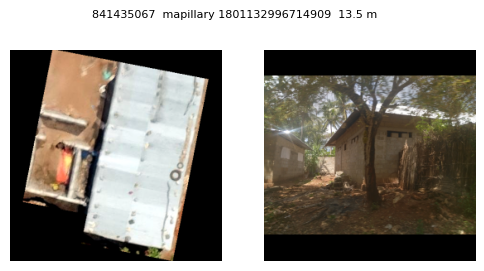

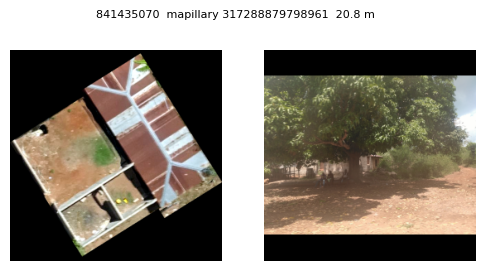

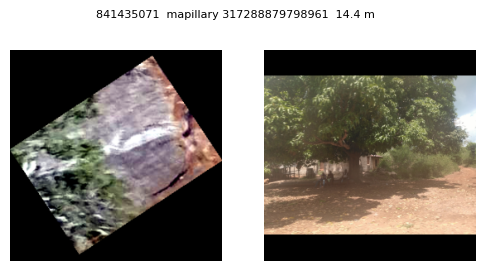

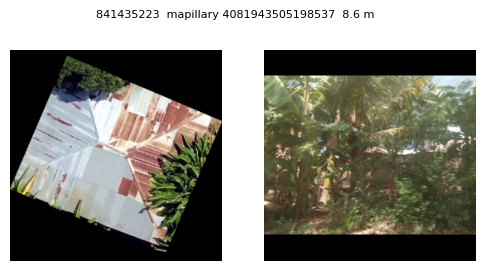

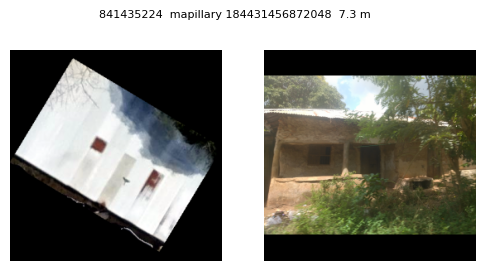

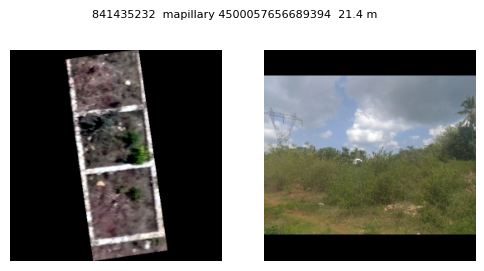

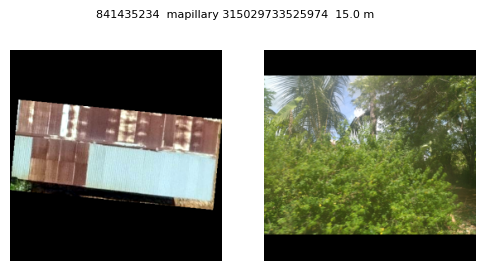

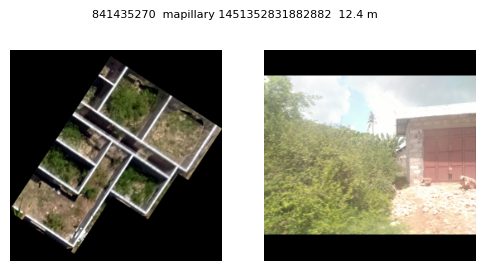

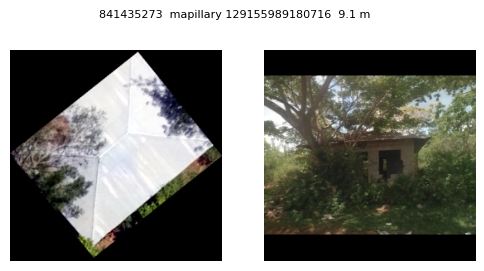

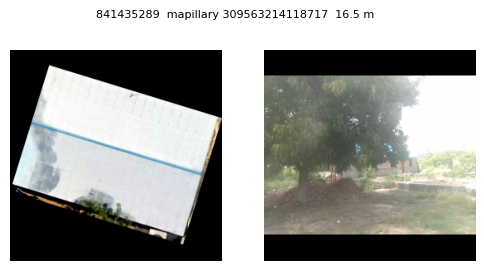

In [5]:
import pandas as pd, matplotlib.pyplot as plt
from PIL import Image
idx = pd.read_csv(f'submission/pairs_index_{NAME}.csv', dtype=str)
for r in idx.head(12).itertuples():
    fig, ax = plt.subplots(1, 2, figsize=(6, 3))
    for a, v in zip(ax, ('uav', 'svi')):
        a.imshow(Image.open(f'submission/{v}/{r.osm_id}.png')); a.axis('off')
    fig.suptitle(f'{r.osm_id}  mapillary {r.mapillary_id}  {r.distance_m} m', fontsize=8)
plt.show()

## 5. Label (option A: here in the notebook)
Option B: the **Label** tab in the QGIS plugin. Option C: Label Studio (see README). All write the same `submission/labels_<NAME>.csv`.

In [6]:
import ipywidgets as w
from IPython.display import display, clear_output
from utils.labels import VOCAB, LABEL_COLUMNS
csv = f'submission/labels_{NAME}.csv'
df = pd.read_csv(csv, dtype=str, keep_default_na=False)
todo = list(df.index[(df[LABEL_COLUMNS] == '').any(axis=1)])
dropdowns = {c: w.Dropdown(options=VOCAB[c], description=c, style={'description_width': '150px'}) for c in LABEL_COLUMNS}
out = w.Output()
def show():
    with out:
        clear_output(wait=True)
        if not todo:
            print('All pairs labelled.'); return
        oid = df.at[todo[0], 'osm_id']
        print(f'{oid}  ({len(todo)} left)')
        display(w.HBox([w.Image(value=open(f'submission/{v}/{oid}.png', 'rb').read(), width=384) for v in ('uav', 'svi')]))
def save(_):
    i = todo.pop(0)
    for c, d in dropdowns.items():
        df.at[i, c] = d.value
    df.to_csv(csv, index=False)
    show()
btn = w.Button(description='Save and next', button_style='success'); btn.on_click(save)
display(w.VBox([out, *dropdowns.values(), btn])); show()

## 6. Validate before uploading

In [7]:
run('04_validate_submission.py', '--name', NAME)

$ c:\Users\gisadmin\miniconda3\envs\geotessera_env\python.exe scripts/04_validate_submission.py --name your_name
ERROR 841435067: structural_openness='' not in ['closed_structure', 'open_structure', 'unknown']
ERROR 841435070: structural_openness='' not in ['closed_structure', 'open_structure', 'unknown']
ERROR 841435071: structural_openness='' not in ['closed_structure', 'open_structure', 'unknown']
ERROR 841435223: structural_openness='' not in ['closed_structure', 'open_structure', 'unknown']
ERROR 841435224: structural_openness='' not in ['closed_structure', 'open_structure', 'unknown']
ERROR 841435232: structural_openness='' not in ['closed_structure', 'open_structure', 'unknown']
ERROR 841435234: structural_openness='' not in ['closed_structure', 'open_structure', 'unknown']
ERROR 841435270: structural_openness='' not in ['closed_structure', 'open_structure', 'unknown']
ERROR 841435273: structural_openness='' not in ['closed_structure', 'open_structure', 'unknown']
ERROR 84143528

RuntimeError: 04_validate_submission.py failed with exit code 1